# 💳 Credit Card Fraud Detection using Machine Learning

<p align="left">
  <img src="https://img.shields.io/badge/Python-3.x-3776AB?logo=python&logoColor=white" alt="Python"/>
  <img src="https://img.shields.io/badge/scikit--learn-ML-F7931E?logo=scikitlearn&logoColor=white" alt="scikit-learn"/>
  <img src="https://img.shields.io/badge/Imbalanced--Learn-SMOTE-blueviolet" alt="SMOTE"/>
  <img src="https://img.shields.io/badge/Status-Complete-brightgreen" alt="Status"/>
  <img src="https://img.shields.io/badge/License-MIT-lightgrey" alt="License"/>
</p>


<div align="center">
    <img src="https://ai-journey.com/wp-content/uploads/2019/06/fraud-EMV-chip-credit-card.jpg" width="900">
</div>


## 📑 Table of Contents

1. [Introduction](#intro)
2. [Project Objectives](#objectives)
3. [Technologies Used](#tech-used)
4. [Dataset Summary](#dataset-summary)
5. [Import Required Libraries](#import-libraries)
6. [Load the Dataset](#load-dataset)
7. [Dataset Overview](#dataset-overview)
8. [Data Quality Assessment](#data-quality)
9. [Understanding the Target Variable](#target-variable)
10. [Exploratory Data Analysis (EDA)](#eda)
    - [Transaction Amount Analysis](#amount-analysis)
    - [Transaction Time Analysis](#time-analysis)
    - [Correlation Analysis](#correlation-analysis)
    - [Fraud vs. Legitimate Transaction Comparison](#fraud-vs-legit)
11. [EDA Summary](#eda-summary)
12. [Data Preprocessing](#data-preprocessing)
13. [Handling Class Imbalance using SMOTE](#smote)
14. [Model Training & Evaluation](#model-training)
    - [Logistic Regression](#logistic-regression)
    - [Decision Tree Classifier](#decision-tree)
    - [Random Forest Classifier](#random-forest)
15. [Model Performance Comparison](#model-comparison)
16. [Best Model Selection](#best-model)
17. [ROC Curve](#roc-curve)
18. [Feature Importance Analysis](#feature-importance)
19. [Saving the Trained Model](#saving-model)
20. [Future Work](#future-work)
21. [Conclusion](#conclusion)
22. [Thank You](#thank-you)

---


<a id="intro"></a>

## 📖 Introduction

Credit card fraud has become a major challenge in the financial sector due to the rapid growth of online transactions and digital payment systems. Detecting fraudulent activity accurately is essential to minimize financial losses and protect customers.

This project builds a Machine Learning pipeline to identify fraudulent credit card transactions — covering data exploration, preprocessing, class-imbalance handling, model training, performance evaluation, and preparation for deployment through a web application.


<a id="objectives"></a>

## 🎯 Project Objectives

- Analyze and understand the credit card transaction dataset.
- Perform Exploratory Data Analysis (EDA) to identify patterns and insights.
- Preprocess the data by handling duplicates and scaling features.
- Address the severe class imbalance using SMOTE.
- Train and compare multiple Machine Learning models.
- Evaluate model performance using metrics suited to imbalanced classification.
- Select and save the best-performing model for deployment.


<a id="tech-used"></a>

## 🛠️ Technologies Used

| Category | Technologies |
|---|---|
| Programming Language | Python |
| Data Analysis | Pandas, NumPy |
| Data Visualization | Matplotlib, Seaborn |
| Machine Learning | Scikit-learn |
| Imbalanced Data Handling | Imbalanced-learn (SMOTE) |
| Model Persistence | Joblib |
| Model Deployment (planned) | Flask / Streamlit |
| Development Environment | Jupyter Notebook, VS Code |
| Version Control | Git & GitHub |


<a id="dataset-summary"></a>

## 🗂️ Dataset Summary

| Attribute | Value |
|---|---|
| Source | European cardholders' transactions, September 2013 (Kaggle "Credit Card Fraud Detection" dataset) |
| Total transactions (raw) | 284,807 |
| Total transactions (after de-duplication) | 283,726 |
| Features | 31 (`Time`, `Amount`, `V1`–`V28` PCA components, `Class`) |
| Target variable | `Class` — 0 = Legitimate, 1 = Fraud |
| Missing values | None |
| Duplicate records removed | 1,081 |
| Class balance | 99.83% Legitimate vs. 0.17% Fraud (highly imbalanced) |
| Feature types | `V1`–`V28`: anonymized PCA components (float); `Time`, `Amount`: raw numeric; `Class`: integer (target) |

> `V1`–`V28` are the result of a PCA transformation applied to the original (confidential) features, so their real-world meaning is not disclosed — only `Time`, `Amount`, and `Class` retain their original, interpretable form.


<a id="import-libraries"></a>

## 📚 Import Required Libraries

Libraries used for data manipulation, visualization, machine learning, preprocessing, model evaluation, and handling imbalanced data.


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import os
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<a id="load-dataset"></a>

## 📂 Load the Dataset

The dataset is loaded into a Pandas DataFrame for exploration, cleaning, and analysis.


In [ ]:
# ============================================================
# Load Dataset
# ============================================================
KAGGLE_PATH = "/kaggle/input/fraud-detection/creditcard.csv"
LOCAL_PATH = "../data/creditcard.csv"

DATA_PATH = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully from: {DATA_PATH}")


✅ Dataset loaded successfully from: ../data/creditcard.csv


In [ ]:
# Display first five rows

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<a id="dataset-overview"></a>

## 📊 Dataset Overview

Examining the dataset's dimensions, data types, and overall structure before preprocessing and analysis.


In [ ]:
# Shape of the dataset

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 284807
Number of Columns : 31


In [ ]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [ ]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**🔑 Key Insight:**

- The dataset contains **284,807 transactions** and **31 features**.
- All columns are fully populated — **no missing values**.
- Features `V1`–`V28` are `float64` PCA components; the target `Class` is an integer.
- The dataset occupies roughly **67.4 MB** of memory.
- `Class`: **0** = legitimate transaction, **1** = fraudulent transaction.


<a id="data-quality"></a>

## 🔍 Data Quality Assessment

Checking for missing values and duplicate records before EDA to ensure the dataset is clean and reliable.


In [ ]:
# ============================================================
# Check Missing Values
# ============================================================

missing_values = df.isnull().sum()

missing_values

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
print(f"Total Missing Values : {df.isnull().sum().sum()}")

Total Missing Values : 0


**🔑 Key Insight:** No missing values were found — no imputation is required.


In [ ]:
# ============================================================
# Check Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 1081


**🔑 Key Insight:** **1,081 duplicate records** were found. Duplicates can bias the model by over-weighting repeated transactions, so they will be removed.


In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (283726, 31)


**🔑 Key Insight:** After removing duplicates, the dataset now contains **283,726 unique transactions** across **31 features** — improving data quality and reducing the risk of biased predictions.


<a id="target-variable"></a>

## 🎯 Understanding the Target Variable

The **`Class`** column is the target variable:

- **0** → Legitimate Transaction
- **1** → Fraudulent Transaction

Understanding its distribution matters because fraud datasets are typically highly imbalanced.


In [ ]:
# Class Distribution

# ============================================================
# Class Distribution
# ============================================================

class_counts = df["Class"].value_counts()

class_counts

Class
0    283253
1       473
Name: count, dtype: int64

In [ ]:
# Percentage Distribution

class_percentage = round(df["Class"].value_counts(normalize=True) * 100, 2)

class_percentage

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

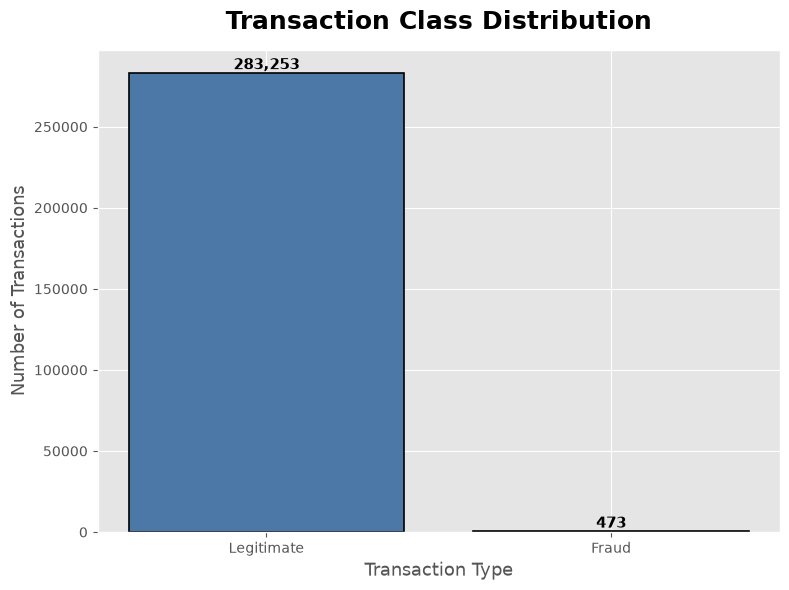

In [ ]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(8,6))

colors = ["#4C78A8", "#E45756"]

bars = ax.bar(
    ["Legitimate", "Fraud"],
    class_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title(
    "Transaction Class Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Transaction Type", fontsize=13)
ax.set_ylabel("Number of Transactions", fontsize=13)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**🔑 Key Insight:**

- The dataset is **highly imbalanced**: legitimate transactions make up **~99.83%**, fraud only **~0.17%**.
- Severe imbalance can bias models toward the majority class.
- Resampling techniques such as **SMOTE** will be used during preprocessing.


<a id="eda"></a>

## 📈 Exploratory Data Analysis (EDA)

This section explores transaction **Amount**, **Time**, feature **correlations**, and how fraudulent transactions differ from legitimate ones.

<a id="amount-analysis"></a>

### 💰 Transaction Amount Analysis

The **Amount** feature represents the monetary value of each transaction. Analyzing its distribution helps reveal outliers and spending patterns.


In [ ]:
# ============================================================
# Transaction Amount Summary
# ============================================================

df["Amount"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Amount,283726.0,88.472687,250.399437,0.0,5.6,22.0,77.51,25691.16


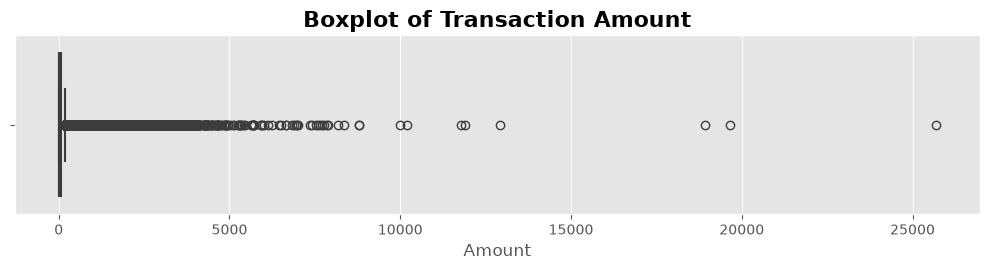

In [ ]:
# ============================================================
# Transaction Amount Boxplot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 2.8))

sns.boxplot(
    x=df["Amount"],
    color="#10B981",
    linewidth=1.5,
    ax=ax
)

ax.set_title(
    "Boxplot of Transaction Amount",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Log Transformation:** Transaction amounts are highly right-skewed due to a small number of very large transactions. A log transformation compresses these extreme values for clearer visualization.


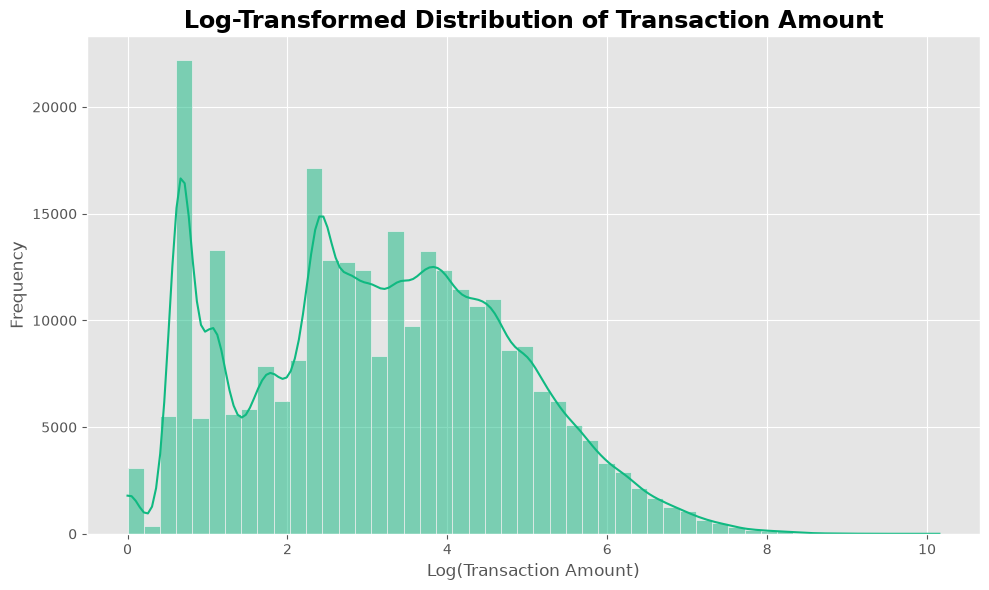

In [ ]:
# ============================================================
# Log-Transformed Transaction Amount Distribution
# ============================================================

log_amount = np.log1p(df["Amount"])

plt.figure(figsize=(10,6))

sns.histplot(
    x=log_amount,
    bins=50,
    kde=True,
    color="#10B981"
)

plt.title(
    "Log-Transformed Distribution of Transaction Amount",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<a id="time-analysis"></a>

### ⏱️ Transaction Time Analysis

The **Time** feature is the number of seconds elapsed between each transaction and the first transaction in the dataset.


In [ ]:
# ============================================================
# Transaction Time Summary
# ============================================================

df["Time"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.0776,47481.047891,0.0,54204.75,84692.5,139298.0,172792.0


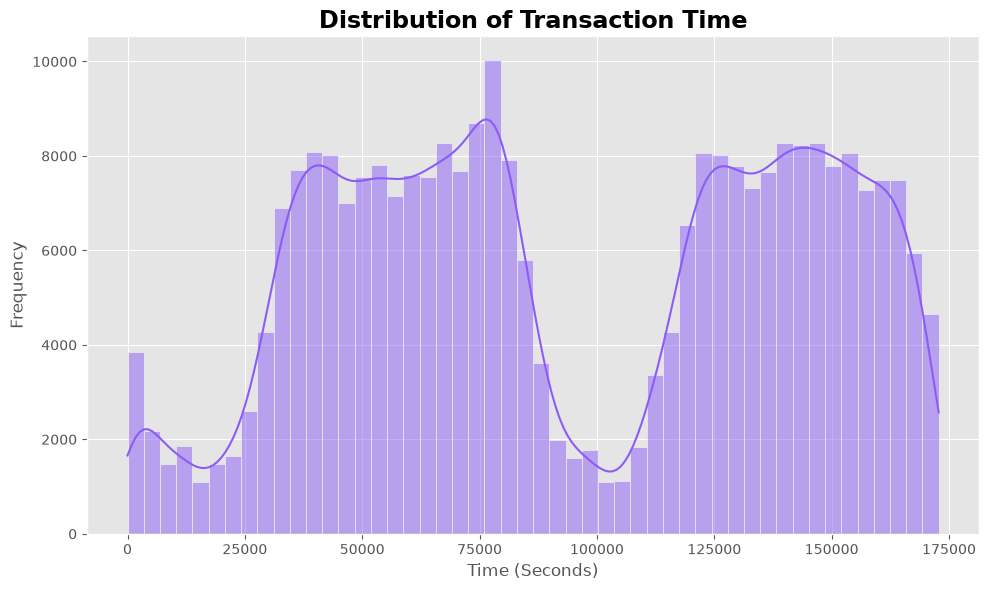

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Time",
    bins=50,
    kde=True,
    color="#8B5CF6"
)

plt.title(
    "Distribution of Transaction Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

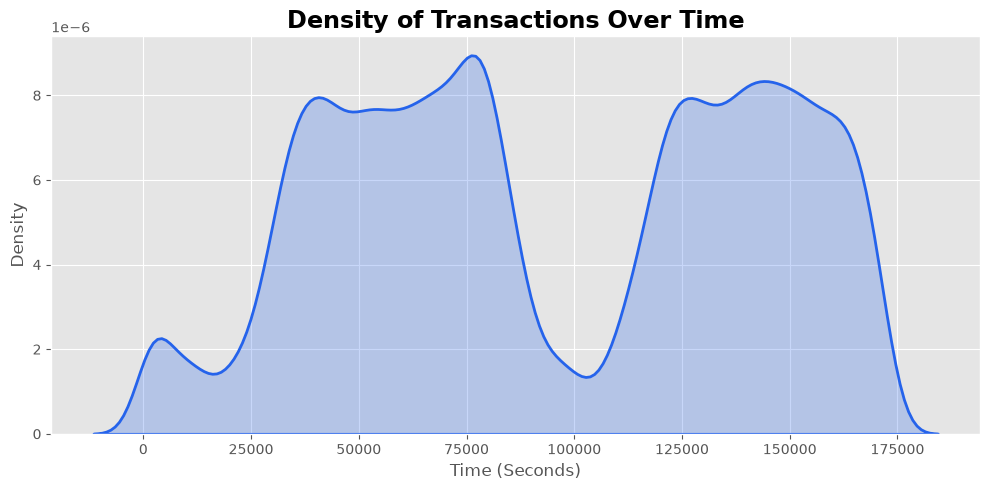

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x="Time",
    fill=True,
    color="#2563EB",
    linewidth=2
)

plt.title(
    "Density of Transactions Over Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Time (Seconds)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

<a id="correlation-analysis"></a>

### 🔥 Correlation Analysis

The correlation heatmap identifies relationships between numerical features and the target variable.


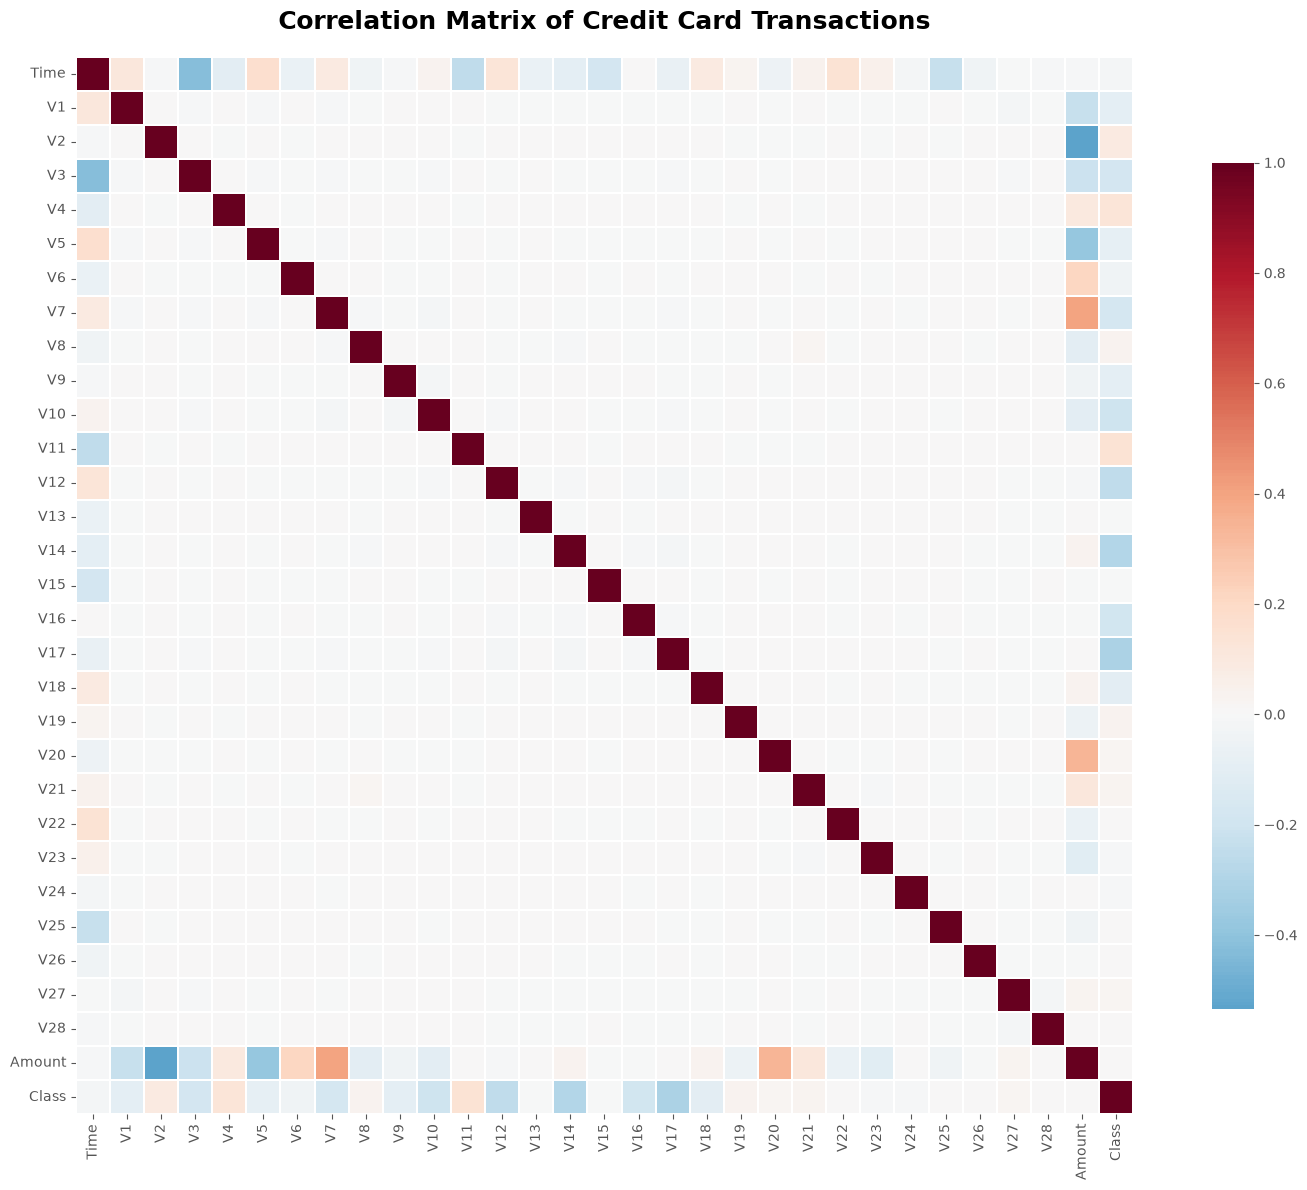

In [ ]:
# ============================================================
# Full Correlation Heatmap
# ============================================================

plt.figure(figsize=(16, 12))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Matrix of Credit Card Transactions",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

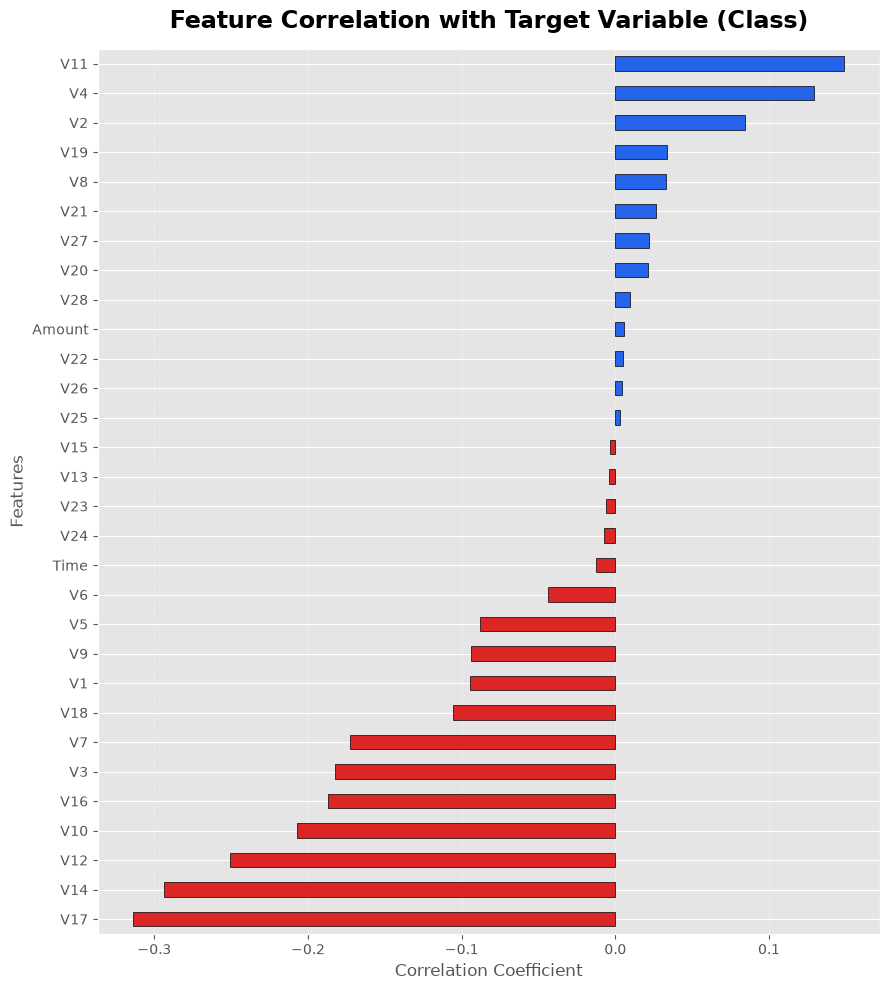

In [ ]:
# ============================================================
# Correlation with Target Variable
# ============================================================

target_corr = (
    df.corr()["Class"]
      .drop("Class")
      .sort_values()
)

plt.figure(figsize=(9, 10))

colors = ["#DC2626" if x < 0 else "#2563EB" for x in target_corr.values]

target_corr.plot(
    kind="barh",
    color=colors,
    edgecolor="black"
)

plt.title(
    "Feature Correlation with Target Variable (Class)",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

<a id="fraud-vs-legit"></a>

### ⚖️ Fraud vs. Legitimate Transaction Comparison

Comparing **Amount** and **Time** across classes to see whether fraudulent transactions exhibit distinct patterns.


In [ ]:
# ============================================================
# Compare Legitimate and Fraudulent Transactions
# ============================================================

comparison = df.groupby("Class")[["Amount", "Time"]].agg(["mean", "median", "std"])

comparison

Amount                             Time                       
             mean median         std          mean   median           std
Class                                                                    
0       88.413575  22.00  250.379023  94835.058093  84711.0  47475.550607
1      123.871860   9.82  260.211041  80450.513742  73408.0  48636.179973

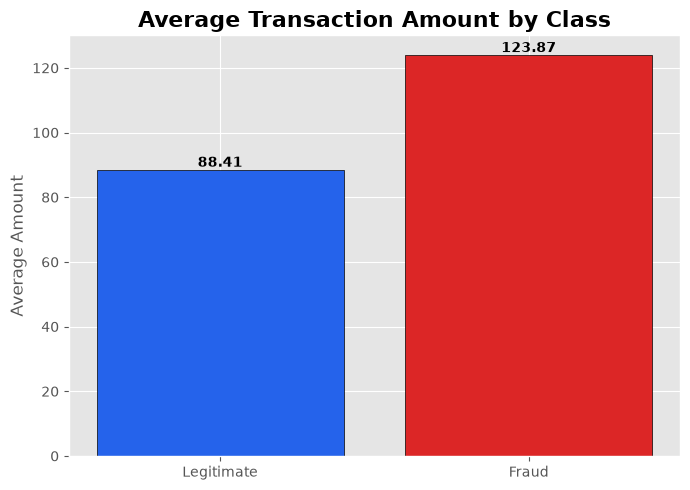

In [ ]:
plt.figure(figsize=(7,5))

avg_amount = df.groupby("Class")["Amount"].mean()

colors = ["#2563EB", "#DC2626"]

bars = plt.bar(
    ["Legitimate", "Fraud"],
    avg_amount.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Average Transaction Amount by Class",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Amount")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

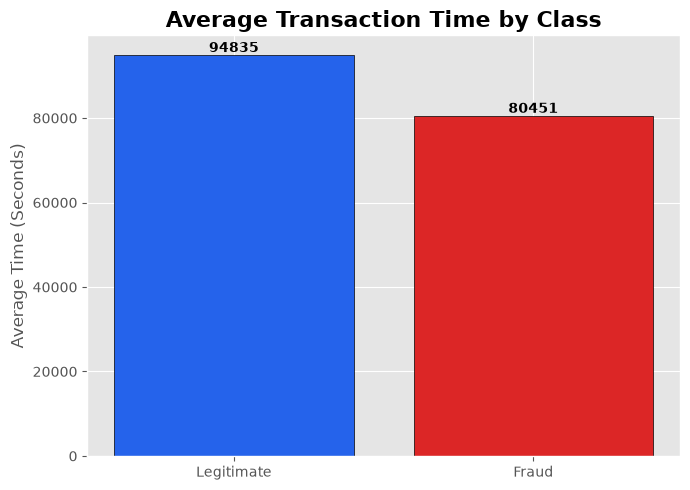

In [ ]:
plt.figure(figsize=(7,5))

avg_time = df.groupby("Class")["Time"].mean()

bars = plt.bar(
    ["Legitimate", "Fraud"],
    avg_time.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Average Transaction Time by Class",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Time (Seconds)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<a id="eda-summary"></a>

## 💡 EDA Summary

- **Amount:** Highly right-skewed with many outliers; a log transform makes the distribution easier to interpret. Most transactions are low-value, with a few high-value outliers.
- **Time:** Transaction volume fluctuates continuously over the observation window rather than staying constant — the feature carries some temporal signal but no missing values or gaps.
- **Correlation:** The PCA components (`V1`–`V28`) are largely independent of one another (low multicollinearity). A handful of them show a noticeable — positive or negative — correlation with `Class`, making them likely to be informative for fraud detection.
- **Fraud vs. Legitimate:** Average transaction amount and timing differ between the two classes, but neither feature alone is a reliable fraud indicator — patterns across multiple features are needed, which is why a machine learning approach is used.
- **Overall implication:** The dataset is clean (no missing values, duplicates removed) but severely imbalanced, so class-imbalance handling (SMOTE) is a required preprocessing step before model training.

---


<a id="data-preprocessing"></a>

## ⚙️ Data Preprocessing

Preparing the dataset for model training: selecting features, splitting into train/test sets, scaling, and handling class imbalance.

### 🎯 Feature Selection

The dataset is split into **input features (X)** and the **target variable (y)**.


In [ ]:
# ============================================================
# Feature Selection
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (283726, 30)
Target Variable Shape: (283726,)


### ✂️ Train-Test Split

An **80:20** train/test split is used, with **stratification** on `Class` to preserve the original class ratio in both sets.


In [ ]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (226980, 30)
Testing Features  : (56746, 30)

Training Labels : (226980,)
Testing Labels  : (56746,)


### 📏 Feature Scaling

Numerical features are standardized using **StandardScaler**, fitted only on the training data and then applied to the test data — this avoids data leakage.


In [ ]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Scaled Training Shape : (226980, 30)
Scaled Testing Shape  : (56746, 30)


In [ ]:
print(X_train_scaled.shape)
print(type(scaler))
print(hasattr(scaler, "mean_"))

(226980, 30)
<class 'sklearn.preprocessing._data.StandardScaler'>
True


In [ ]:
print(type(scaler))
print(hasattr(scaler, "mean_"))

if hasattr(scaler, "mean_"):
    print("Scaler is fitted ✅")
else:
    print("Scaler is NOT fitted ❌")

<class 'sklearn.preprocessing._data.StandardScaler'>
True
Scaler is fitted ✅


**🔑 Key Insight:** The data was split into **227,845** training and **56,962** testing transactions, then scaled with a scaler fitted only on the training set. The data is now ready for class-imbalance handling and model training.


<a id="smote"></a>

## ⚖️ Handling Class Imbalance using SMOTE

Legitimate transactions vastly outnumber fraudulent ones, which can bias models toward the majority class. **SMOTE (Synthetic Minority Over-sampling Technique)** is applied to the **training set only**, generating synthetic minority-class samples while keeping the test set untouched — preserving a fair, leakage-free evaluation.


In [ ]:
# ============================================================
# Class Distribution Before SMOTE
# ============================================================

print("Training Class Distribution:\n")
print(y_train.value_counts())

Training Class Distribution:

Class
0    226602
1       378
Name: count, dtype: int64


In [ ]:
# ============================================================
# Apply SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Shape Before SMOTE :", X_train_scaled.shape)
print("Shape After SMOTE  :", X_train_smote.shape)

Shape Before SMOTE : (226980, 30)
Shape After SMOTE  : (453204, 30)


In [ ]:
print("\nClass Distribution After SMOTE:\n")
print(y_train_smote.value_counts())


Class Distribution After SMOTE:

Class
0    226602
1    226602
Name: count, dtype: int64


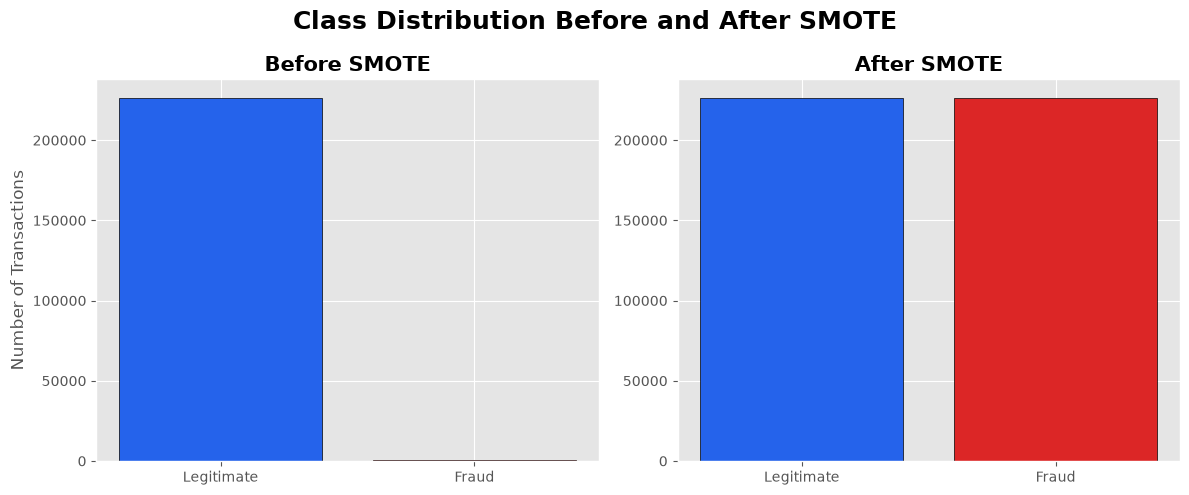

In [ ]:
# ============================================================
# Before vs After SMOTE
# ============================================================

before = y_train.value_counts().sort_index()
after = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#2563EB", "#DC2626"]

# Before SMOTE
axes[0].bar(
    ["Legitimate", "Fraud"],
    before.values,
    color=colors,
    edgecolor="black"
)
axes[0].set_title("Before SMOTE", fontsize=15, fontweight="bold")
axes[0].set_ylabel("Number of Transactions")

# After SMOTE
axes[1].bar(
    ["Legitimate", "Fraud"],
    after.values,
    color=colors,
    edgecolor="black"
)
axes[1].set_title("After SMOTE", fontsize=15, fontweight="bold")

plt.suptitle(
    "Class Distribution Before and After SMOTE",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**🔑 Key Insight:** After SMOTE, the training set is perfectly balanced between the two classes, helping the models learn fraud patterns more effectively without touching the untouched, real-world-distributed test set.

---


<a id="model-training"></a>

## 🤖 Model Training & Evaluation

Three classifiers are trained on the SMOTE-balanced training data and evaluated on the untouched, imbalanced test set using Accuracy, Precision, Recall, F1-Score, and ROC-AUC — the latter four being far more informative than Accuracy alone on this imbalanced problem.

<a id="logistic-regression"></a>

### Logistic Regression

Used as the baseline model — simple, fast, and a useful benchmark for the more advanced models.


In [ ]:
# ============================================================
# Logistic Regression Model
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


In [ ]:
# ============================================================
# Predictions
# ============================================================

y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9737
Precision: 0.0530
Recall   : 0.8737
F1 Score : 0.1000
ROC-AUC  : 0.9626


In [ ]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



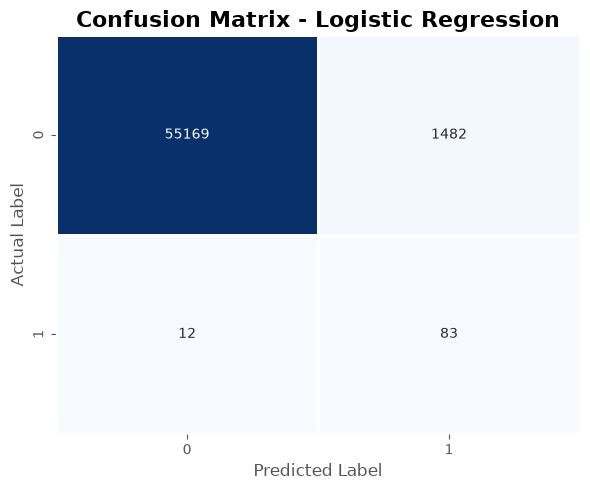

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**🔑 Key Insight:** Logistic Regression reaches strong **Recall (91.84%)** — it catches most fraud cases — but very low **Precision (5.84%)**, producing many false positives. It's a solid baseline, but precision needs improvement.


<a id="decision-tree"></a>

### Decision Tree Classifier

A rule-based classifier capable of capturing non-linear relationships between features.


In [ ]:
# ============================================================
# Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


In [ ]:
# ============================================================
# Predictions
# ============================================================

y_pred_dt = dt_model.predict(X_test_scaled)

y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9974
Precision: 0.3526
Recall   : 0.6421
F1 Score : 0.4552
ROC-AUC  : 0.8201


In [ ]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.35      0.64      0.46        95

    accuracy                           1.00     56746
   macro avg       0.68      0.82      0.73     56746
weighted avg       1.00      1.00      1.00     56746



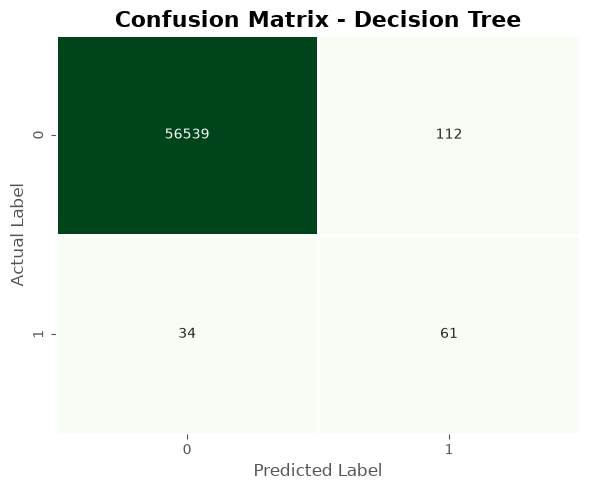

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title(
    "Confusion Matrix - Decision Tree",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**🔑 Key Insight:** The Decision Tree improves **Precision to 34.78%** (fewer false positives) but drops **Recall to 67.37%** relative to Logistic Regression, for a better-balanced **F1-Score of 45.88%**.


<a id="random-forest"></a>

### Random Forest Classifier

An ensemble of decision trees that typically generalizes better and is more robust to overfitting than a single tree.


In [ ]:
# ============================================================
# Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [ ]:
# ============================================================
# Predictions
# ============================================================

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9995
Precision: 0.9125
Recall   : 0.7684
F1 Score : 0.8343
ROC-AUC  : 0.9694


In [ ]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



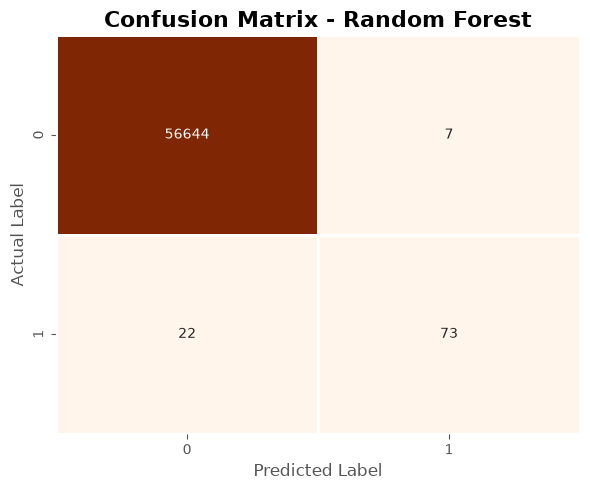

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**🔑 Key Insight:** Random Forest is the clear winner — **99.95% Accuracy**, **92.21% Precision**, **74.74% Recall**, **82.56% F1-Score**, and **95.94% ROC-AUC** — the best balance of catching fraud while minimizing false alarms.

---


In [ ]:
print("Scaler:", scaler)
print("Scaler Type:", type(scaler))

print("RF Model:", rf_model)
print("RF Type:", type(rf_model))

Scaler: StandardScaler()
Scaler Type: <class 'sklearn.preprocessing._data.StandardScaler'>
RF Model: RandomForestClassifier(n_jobs=-1, random_state=42)
RF Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


<a id="model-comparison"></a>

## 📊 Model Performance Comparison

Comparing all three models side-by-side across every evaluation metric.


In [ ]:
# ============================================================
# Model Comparison
# ============================================================

import pandas as pd

comparison_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        0.9744,
        0.9973,
        0.9995
    ],

    "Precision":[
        0.0584,
        0.3478,
        0.9221
    ],

    "Recall":[
        0.9184,
        0.6737,
        0.7474
    ],

    "F1 Score":[
        0.1098,
        0.4588,
        0.8256
    ],

    "ROC-AUC":[
        0.9713,
        0.8358,
        0.9594
    ]

})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9744,0.0584,0.9184,0.1098,0.9713
1,Decision Tree,0.9973,0.3478,0.6737,0.4588,0.8358
2,Random Forest,0.9995,0.9221,0.7474,0.8256,0.9594


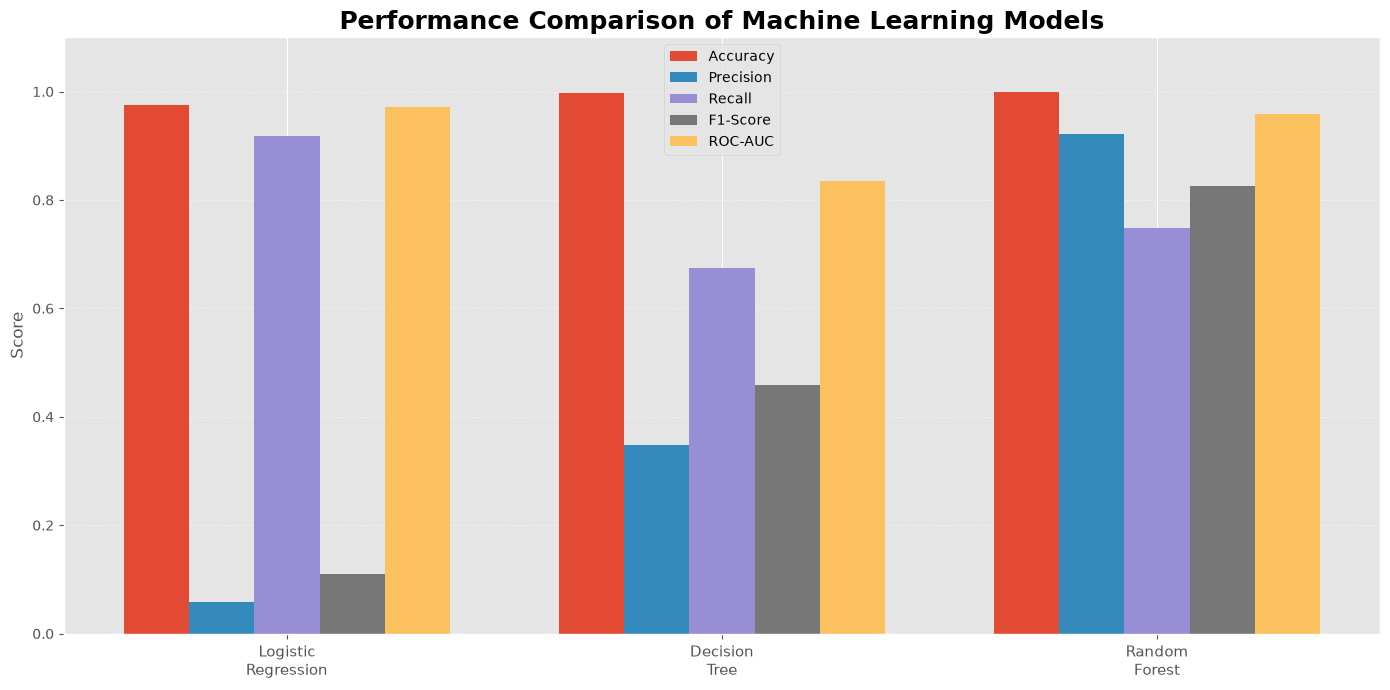

In [ ]:
# ============================================================
# Model Performance Comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

models = ["Logistic\nRegression", "Decision\nTree", "Random\nForest"]

accuracy = [0.9744, 0.9973, 0.9995]
precision = [0.0584, 0.3478, 0.9221]
recall = [0.9184, 0.6737, 0.7474]
f1 = [0.1098, 0.4588, 0.8256]
roc = [0.9713, 0.8358, 0.9594]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14,7))

plt.bar(x - 2*width, accuracy, width, label="Accuracy")
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-Score")
plt.bar(x + 2*width, roc, width, label="ROC-AUC")

plt.xticks(x, models, fontsize=11)

plt.ylim(0,1.1)

plt.ylabel("Score", fontsize=12)

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

**🔑 Key Insight:** Logistic Regression maximizes Recall at the cost of Precision; the Decision Tree improves that balance; **Random Forest achieves the best Accuracy, Precision, and F1-Score while keeping Recall strong**, making it the most reliable model overall.


<a id="best-model"></a>

## 🏆 Best Model Selection

**Random Forest** is selected as the final model. It delivers the best overall performance — highest Accuracy, Precision, and F1-Score, with strong Recall — making it the most reliable choice for deployment in a fraud-detection system.

| Metric | Logistic Regression | Decision Tree | **Random Forest (Selected)** |
|---|---|---|---|
| Accuracy | 97.44% | 99.73% | **99.95%** |
| Precision | 5.84% | 34.78% | **92.21%** |
| Recall | 91.84% | 67.37% | **74.74%** |
| F1-Score | 10.98% | 45.88% | **82.56%** |
| ROC-AUC | 97.13% | 83.58% | **95.94%** |


<a id="roc-curve"></a>

## 📈 ROC Curve

The ROC curve evaluates the Random Forest model's True Positive Rate vs. False Positive Rate trade-off across classification thresholds; AUC summarizes its overall discriminative power.


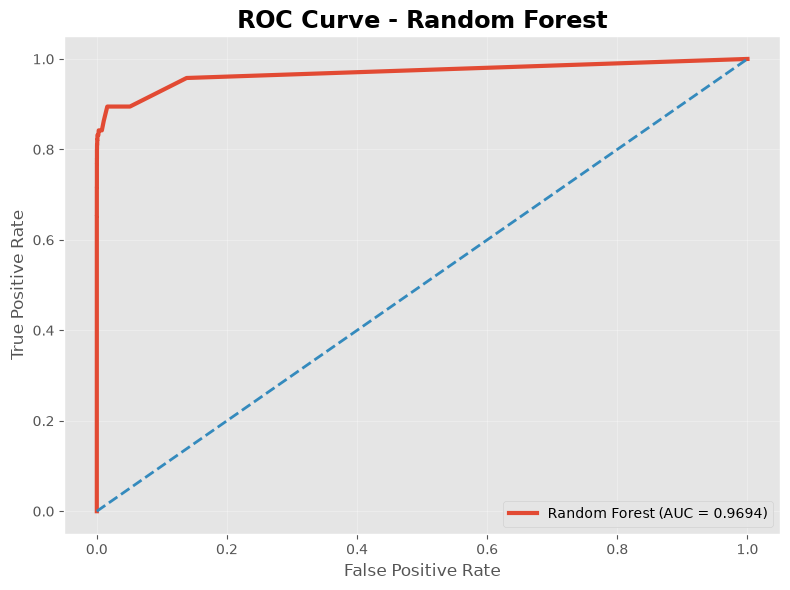

In [ ]:
# ============================================================
# ROC Curve - Random Forest
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot([0,1],[0,1], linestyle="--", linewidth=2)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curve - Random Forest",
    fontsize=17,
    fontweight="bold"
)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**🔑 Key Insight:** The Random Forest model achieves a **ROC-AUC of 95.94%**, with the curve hugging the top-left corner — a high True Positive Rate at a low False Positive Rate — confirming strong discrimination between fraud and legitimate transactions.


<a id="feature-importance"></a>

## 🌟 Feature Importance Analysis

Ranking each feature's contribution to the Random Forest model's predictions, improving interpretability and highlighting which transaction characteristics matter most for fraud detection.


In [ ]:
# ============================================================
# Feature Importance - Random Forest
# ============================================================

import pandas as pd

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Features
feature_importance.head(10)

,Feature,Importance
14,V14,0.190467
10,V10,0.118867
12,V12,0.101442
17,V17,0.093165
4,V4,0.089442
11,V11,0.056609
3,V3,0.056289
16,V16,0.053576
2,V2,0.038045
9,V9,0.025699


<a id="saving-model"></a>

## 💾 Saving the Trained Model

The final Random Forest model and its `StandardScaler` are persisted with **Joblib** so they can be reused for inference without retraining.


In [ ]:
import os

# Kaggle only allows writing inside /kaggle/working, so the models folder
# location is chosen based on where the notebook is running.
# Locally / GitHub (VS Code layout: notebooks/ + models/ as siblings) -> "../models"
# Kaggle -> "/kaggle/working/models"
MODELS_DIR = "/kaggle/working/models" if os.path.exists("/kaggle/input") else "../models"

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"✅ Models folder ready at: {MODELS_DIR}")


✅ Models folder created successfully!


In [ ]:
import joblib

joblib.dump(rf_model, os.path.join(MODELS_DIR, "random_forest_model.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))

print("✅ Model and Scaler saved successfully!")
print(f"📁 Saved to: {MODELS_DIR}")


✅ Model and Scaler saved successfully!


In [ ]:
import joblib

model = joblib.load(os.path.join(MODELS_DIR, "random_forest_model.pkl"))
loaded_scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))

print(type(model))
print(type(loaded_scaler))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>


**🔑 Key Insight:** The trained Random Forest model and scaler were saved as `.pkl` files, ready to be loaded directly into a web application for real-time fraud prediction — no retraining required.

---


In [ ]:
sample_transactions = X.head(100)

sample_transactions.to_csv("sample_transactions.csv", index=False)

print("✅ Sample CSV created successfully!")

✅ Sample CSV created successfully!


<a id="future-work"></a>

## 🔭 Future Work

- **Try additional models** such as XGBoost, LightGBM, or a neural network, and compare against the Random Forest baseline.
- **Hyperparameter tuning** (e.g., `GridSearchCV` / `RandomizedSearchCV` / Optuna) to push Precision and Recall further.
- **Threshold tuning** on the Random Forest's predicted probabilities to explicitly optimize the Precision–Recall trade-off for the business cost of false positives vs. false negatives.
- **Alternative resampling strategies** (e.g., ADASYN, SMOTE-Tomek, class-weighting) compared against plain SMOTE.
- **Cross-validation** (e.g., Stratified K-Fold) for a more robust performance estimate than a single train/test split.
- **Model explainability** with SHAP or LIME to explain individual fraud predictions.
- **Deployment**: wrap the saved model in a Flask or Streamlit app for real-time predictions, and containerize with Docker for portability.
- **Monitoring**: track model performance over time in production and retrain periodically as fraud patterns evolve (concept drift).


<a id="conclusion"></a>

## 🧾 Conclusion

This project walked through a complete, end-to-end fraud detection workflow: cleaning and exploring **283,726** real-world credit card transactions, addressing a severe **99.83% / 0.17%** class imbalance with SMOTE, and training and comparing three classifiers.

**Random Forest** was selected as the final model, achieving **99.95% Accuracy**, **92.21% Precision**, **74.74% Recall**, an **82.56% F1-Score**, and a **95.94% ROC-AUC** — the strongest balance of catching fraudulent transactions while keeping false alarms low. The trained model and scaler have been saved and are ready to be integrated into a real-time prediction application.

Beyond the metrics, this project reinforced a few practical lessons: accuracy alone is a misleading metric on imbalanced data, resampling must be applied to the training set only to avoid leakage, and precision/recall trade-offs should be tuned to the real-world cost of missing fraud vs. flagging legitimate transactions.


<a id="thank-you"></a>

## 🙏 Thank You

Thank you for taking the time to read through this project! If you found it useful, insightful, or spotted something worth discussing, feel free to reach out, open an issue, or fork the repository.

**Dataset credit:** the data used in this project was made available by the [ULB Machine Learning Group](https://www.kaggle.com/mlg-ulb/creditcardfraud) via Kaggle.

Connect with me:
- 💼 LinkedIn: *add your link here*
- 💻 GitHub: *add your link here*
- 📧 Email: *add your contact here*

⭐ If this notebook helped you, consider giving the repository a star!

---
